<a href="https://colab.research.google.com/github/Ayush-0918/Netflix-Data-Visualization-Project/blob/main/Netflix_Data_Visualization_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df = pd.read_csv("netflix_titles.csv")

# Remove duplicates

df = df.drop_duplicates()

# Fill missing values

df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna('Not Rated')

# Remove extra spaces

df['date_added'] = df['date_added'].astype(str).str.strip()

# Convert to datetime

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print(df.shape)

print(df.isnull().sum())

(8807, 12)
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [10]:
df = df.dropna(subset=['date_added', 'duration'])

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [12]:
df.to_csv("netflix_cleaned.csv", index=False)


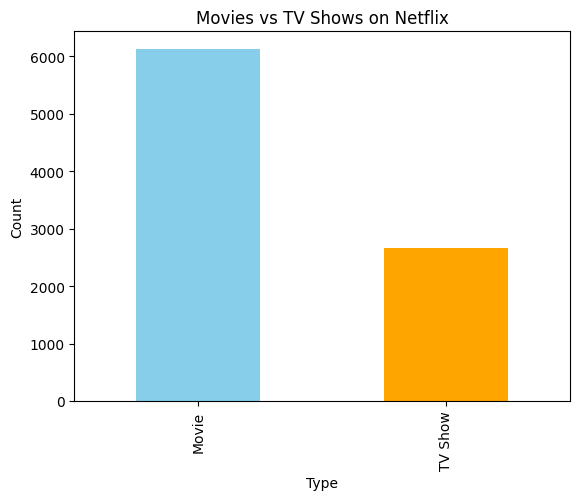

In [13]:
df['type'].value_counts().plot(
    kind='bar',
    color=['skyblue','orange']
)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

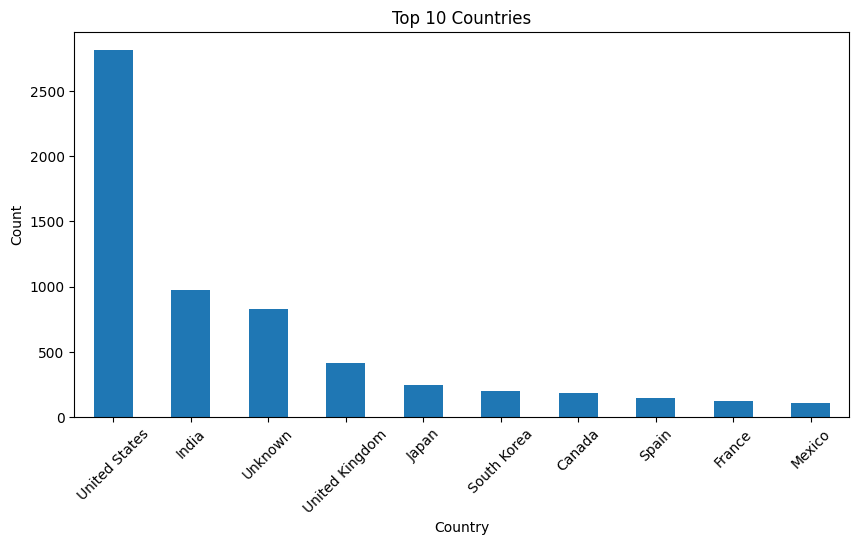

In [14]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_country.plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

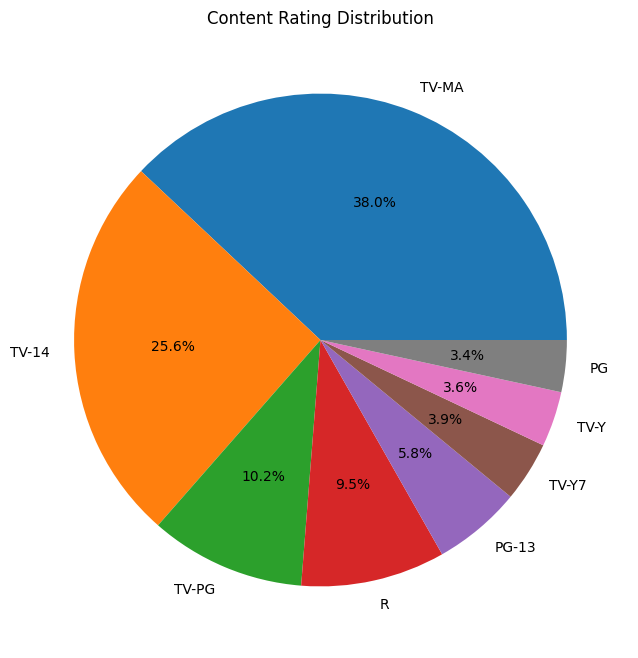

In [15]:
plt.figure(figsize=(8,8))

df['rating'].value_counts().head(8).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Content Rating Distribution")

plt.show()

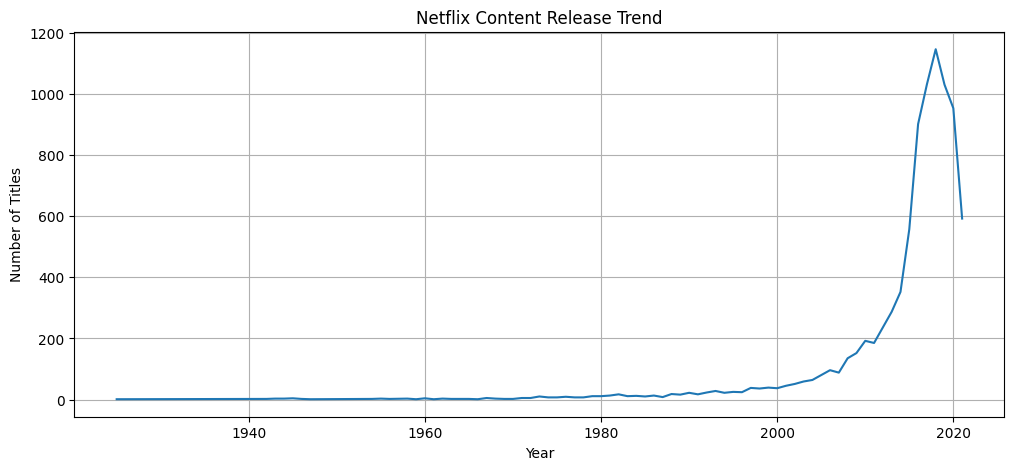

In [16]:
year_data = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(year_data.index, year_data.values)

plt.title("Netflix Content Release Trend")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid()

plt.show()

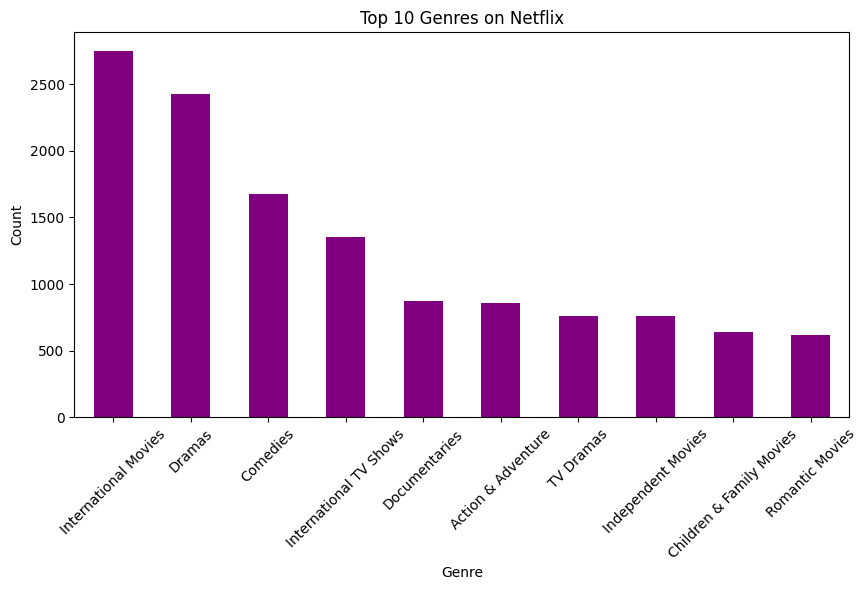

In [17]:
genre_counts = df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar', color='purple')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

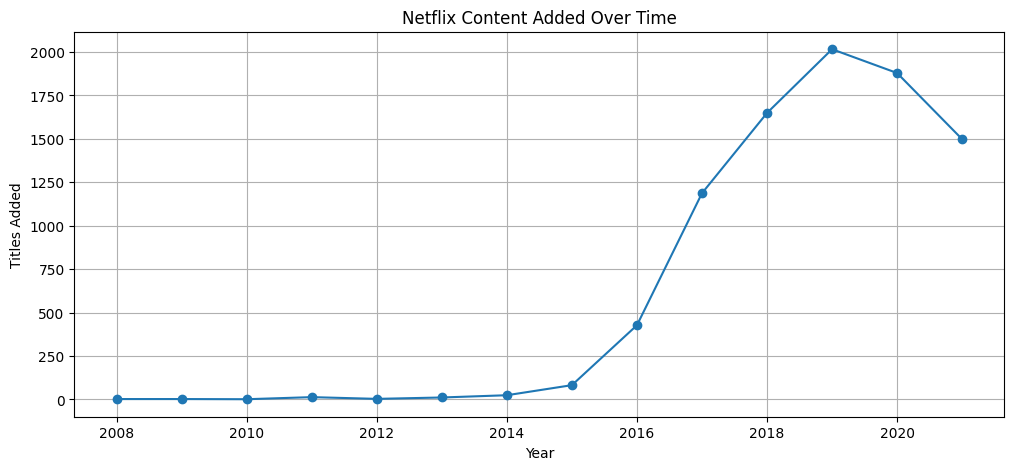

In [18]:
df['year_added'] = df['date_added'].dt.year

growth = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(growth.index, growth.values, marker='o')

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Titles Added")

plt.grid(True)

plt.show()

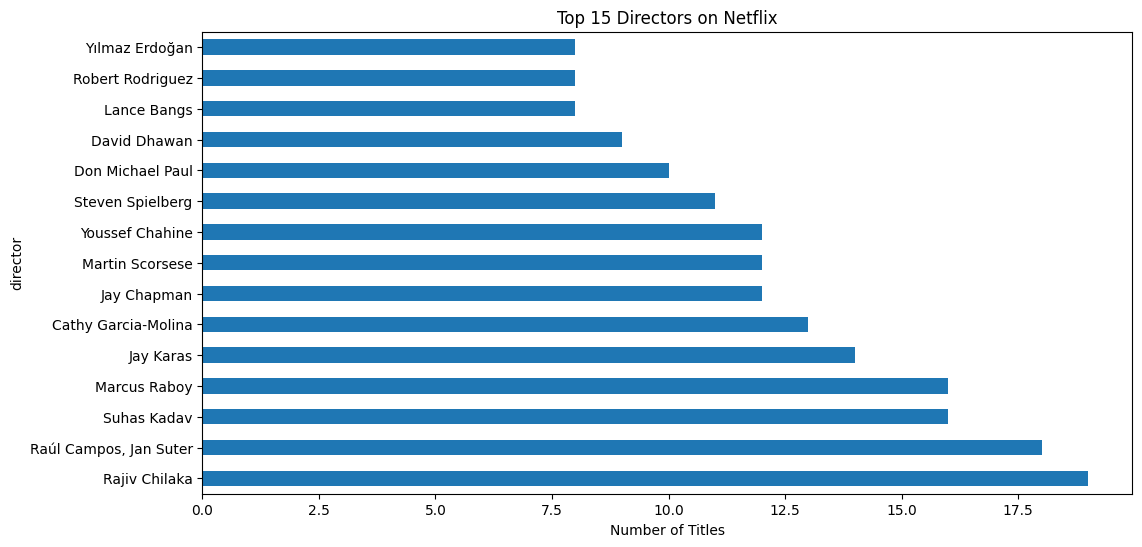

In [19]:
top_directors = (
    df[df['director'] != 'Unknown']
    ['director']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

top_directors.plot(kind='barh')

plt.title("Top 15 Directors on Netflix")
plt.xlabel("Number of Titles")

plt.show()

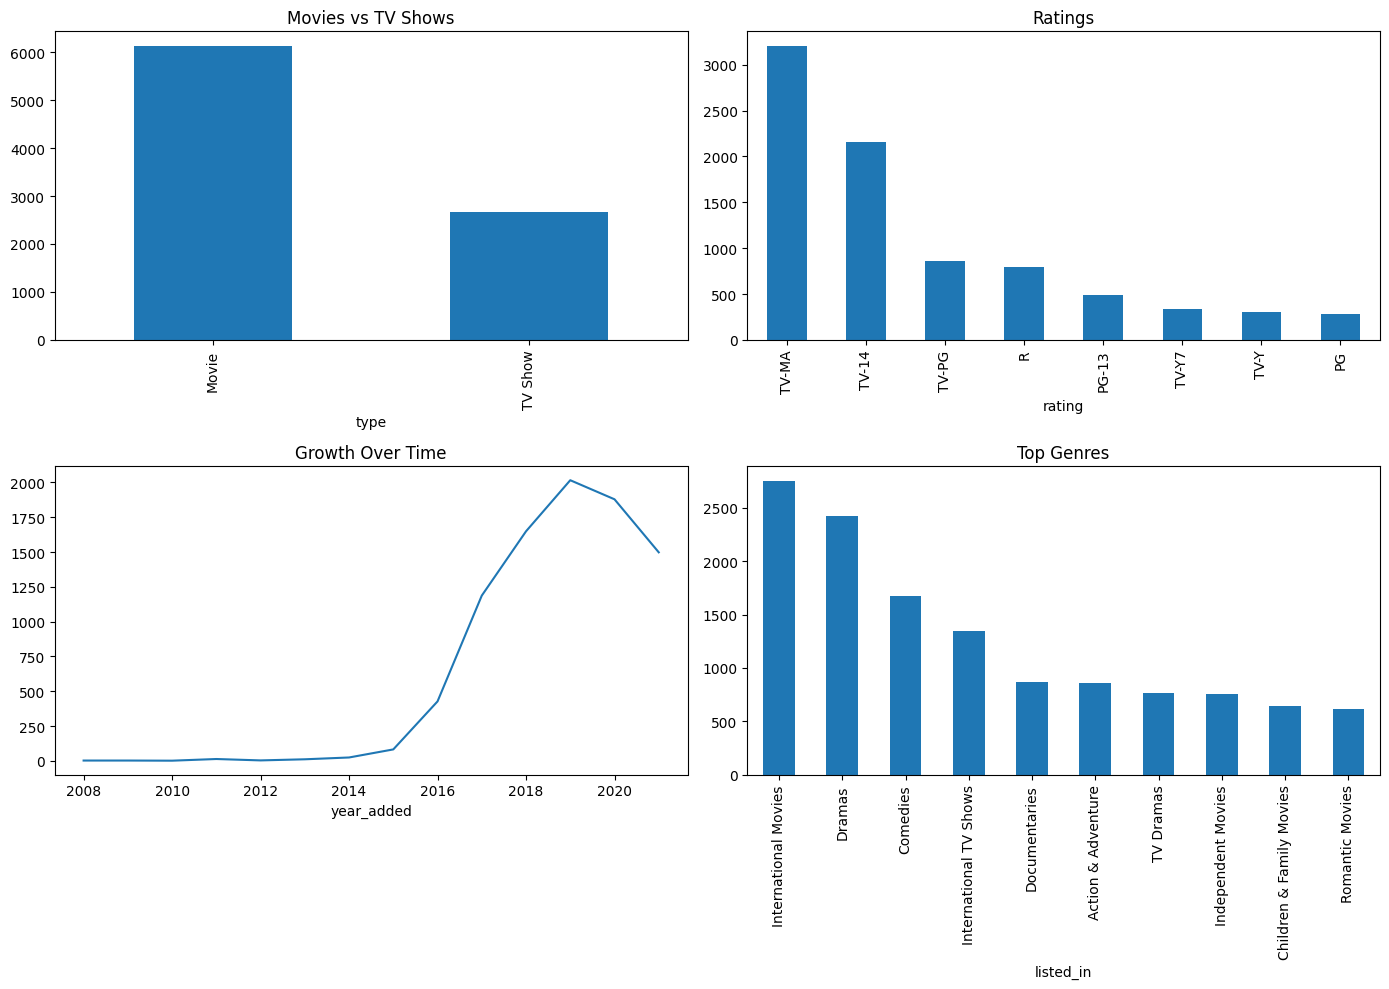

In [20]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

df['type'].value_counts().plot(kind='bar', ax=ax[0,0])
ax[0,0].set_title("Movies vs TV Shows")

df['rating'].value_counts().head(8).plot(kind='bar', ax=ax[0,1])
ax[0,1].set_title("Ratings")

growth.plot(ax=ax[1,0])
ax[1,0].set_title("Growth Over Time")

genre_counts.plot(kind='bar', ax=ax[1,1])
ax[1,1].set_title("Top Genres")

plt.tight_layout()
plt.show()